# ChaosQKT with Psyduck: Quantum Chaos Simulation Tutorial

**Tutorial for Quantum Chaos Simulations using the Psyduck Framework**

This notebook demonstrates quantum chaos dynamics simulations using the **psyduck** library combined with custom helper functions from **ChaosQKT_pd_functions**.

The notebook uses ONLY:
- `psyduck` module (core framework)
- `psyduck.plotting` subfolder (Wigner visualization)
- `ChaosQKT_pd_functions` (custom chaos simulation functions)

NO functions from the `ChaosQKT` package (fitting, math_operations, plotting, utilities) are used.

## Section 1: Setup and Imports

Import psyduck and custom helper functions.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import importlib
import sys

# Force reload of psyduck modules
for module_name in list(sys.modules.keys()):
    if module_name.startswith('psyduck'):
        del sys.modules[module_name]

# Import psyduck library fresh
from psyduck import Spin
from psyduck.plotting import *
from psyduck.evolve import kicked_dynamics

# Import custom ChaosQKT helper functions
import ChaosQKT_functions as qkt

print("✓ Psyduck loaded successfully!")
print("✓ ChaosQKT_functions loaded successfully!")
print(f"\nQuTiP version: {qt.__version__}")

✓ Psyduck loaded successfully!
✓ ChaosQKT_functions loaded successfully!

QuTiP version: 5.2.3


## Section 2: Initialize Spin System

Create a Spin object using psyduck.

In [2]:
# Define spin quantum number
I = 7/2  # Spin-7/2 system (dimension 8)

# Create a Spin object using psyduck
nucleus = Spin(I=I)

print(f"✓ Created Spin system: I = {I}")
print(f"  Hilbert space dimension: {nucleus.dim}")

# Get spin operators from psyduck
Ix, Iy, Iz = nucleus.get_spin_operators()
print(f"✓ Spin operators created (shape: {Ix.shape})")

✓ Created Spin system: I = 3.5
  Hilbert space dimension: 8
✓ Spin operators created (shape: (8, 8))


## Section 3: Create Initial Spin-Coherent State

In [3]:
# Create a spin-coherent state at specific polar angles
theta = 0
phi = 0

# Use the spin.py method to create the displaced coherent state
nucleus.make_displaced_coherent_state(theta=theta, phi=phi)
psi_initial = nucleus.state

print(f"✓ Created initial state at θ={theta:.3f}, φ={phi:.3f}")



✓ Created initial state at θ=0.000, φ=0.000


### 3.1 Visualize Prepared State in Hammer Projection

Plot the Wigner function of the prepared spin-coherent state using Hammer projection.

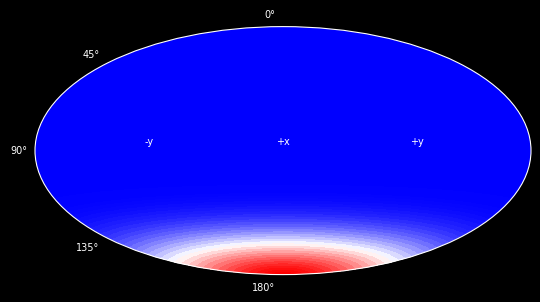

✓ Initial state visualized in Hammer projection
  The sharp peak indicates a well-defined spin-coherent state


In [4]:
# Visualize the prepared state using psyduck's wigner_plot_hammer
fig, ax, _ = wigner_plot_hammer(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr'
)
plt.show()

print("✓ Initial state visualized in Hammer projection")
print(f"  The sharp peak indicates a well-defined spin-coherent state")


### 3.2 Time Evolution and Expectation Values

Calculate expectation values using the `Spin.expectation()` method from psyduck.

In [5]:
# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()

# Calculate expectation values using Spin.expectation() method
exp_Ix = nucleus.expectation(Ix)
exp_Iy = nucleus.expectation(Iy)
exp_Iz = nucleus.expectation(Iz)

print(f"\nExpectation values using nucleus.expectation():")
print(f"  <Jx> = {exp_Ix:.4f}")
print(f"  <Jy> = {exp_Iy:.4f}")
print(f"  <Jz> = {exp_Iz:.4f}")

# Calculate linear entropy using nucleus.qudit_linear_entropy() method
entropy = nucleus.qudit_linear_entropy()
print(f"\nLinear entropy using nucleus.qudit_linear_entropy(): {entropy:.6f}")


Expectation values using nucleus.expectation():
  <Jx> = 0.0000
  <Jy> = 0.0000
  <Jz> = 3.5000

Linear entropy using nucleus.qudit_linear_entropy(): 0.000000


## Section 4: Run Kicked Dynamics Simulation

Simulate the quantum kicked top with nonlinear pulses, then visualize the evolution with an interactive slider showing Wigner functions in Hammer projection after each kick.

In [6]:
# Simulation parameters
tau = 1.0      # Free evolution time between kicks
kappa = 3.5*np.pi    # Kick strength (nonlinearity parameter)
N_kicks = 20   # Number of kicks
order = 2      # Nonlinear kick order

print("Running kicked dynamics simulation...")
print(f"Parameters: tau={tau}, kappa={kappa}, N={N_kicks}, order={order}")

# Use kicked_dynamics from psyduck.evolve
psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
    psi_initial, tau, kappa, I, N=N_kicks, order=order, pulse_type='pulse'
)

print(f"✓ Simulation completed!")
print(f"  Generated {len(psi_list)} states")
print(f"\nChaos Metrics:")
print(f"  Initial entropy: {entropy_list[0]:.6f}")
print(f"  Final entropy: {entropy_list[-1]:.6f}")
print(f"  Entropy increase: {entropy_list[-1] - entropy_list[0]:.6f}")
print(f"  Final overlap: |<ψ(0)|ψ(T)>| = {abs(overlap_list[-1]):.6f}")

Running kicked dynamics simulation...
Parameters: tau=1.0, kappa=10.995574287564276, N=20, order=2
✓ Simulation completed!
  Generated 21 states

Chaos Metrics:
  Initial entropy: 0.000000
  Final entropy: 0.000000
  Entropy increase: 0.000000
  Final overlap: |<ψ(0)|ψ(T)>| = 0.125000


### 4.1 Interactive Wigner Function Visualization with Slider

Use the slider below to explore the Wigner function after each kick. The Hammer projection shows the phase space evolution throughout the simulation.

In [7]:
from ipywidgets import interact, IntSlider

def plot_wigner_evolution(kick_number):
    """Plot Wigner function for the state after a given kick number."""
    fig, ax, _ = wigner_plot_hammer(
        psi_list[kick_number],
        n_theta=101,
        n_phi=201,
        cmap="bwr"
    )
    ax.set_title(
        f"Kick {kick_number}: Wigner Function Evolution\n"
        f"Entropy: {entropy_list[kick_number]:.6f} | "
        f"Overlap: {abs(overlap_list[kick_number]):.6f}",
        fontsize=12,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

# Create interactive slider widget
print("\n" + "="*70)
print("Interactive Wigner Function Visualization")
print("="*70)
print(f"Slide to browse through all {len(psi_list)} states")
print(f"Observe phase space evolution from kick 0 to {N_kicks}")
print("="*70 + "\n")

interact(
    plot_wigner_evolution,
    kick_number=IntSlider(
        min=0,
        max=N_kicks,
        step=1,
        value=0,
        description="Kick:",
        continuous_update=True,
        layout={"width": "500px"}
    )
)


Interactive Wigner Function Visualization
Slide to browse through all 21 states
Observe phase space evolution from kick 0 to 20



interactive(children=(IntSlider(value=0, description='Kick:', layout=Layout(width='500px'), max=20), Output())…

<function __main__.plot_wigner_evolution(kick_number)>

## Section 5: Plot Evolution Metrics

Visualize the system dynamics across all kicks.

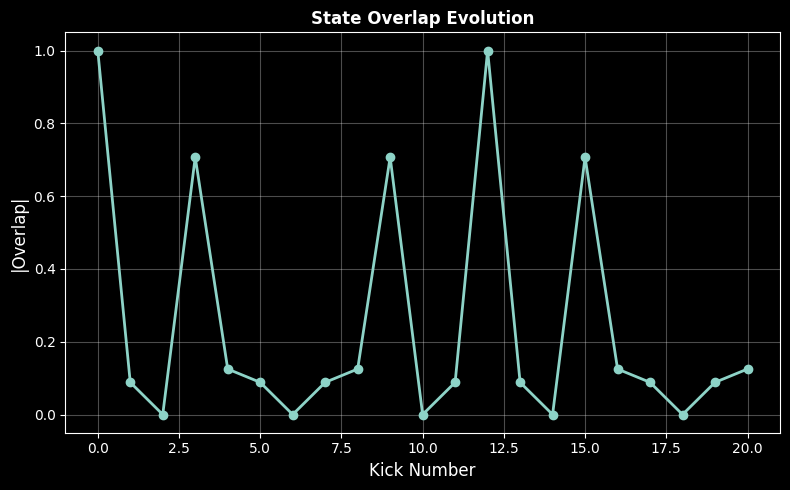

In [8]:
# Plot 1: Overlap evolution
fig_overlap, ax_overlap = plt.subplots(figsize=(8, 5))
ax_overlap.plot(range(len(overlap_list)), abs(np.array(overlap_list)), 'o-', 
                linewidth=2, markersize=6, color='C0')
ax_overlap.set_xlabel('Kick Number', fontsize=12)
ax_overlap.set_ylabel('|Overlap|', fontsize=12)
ax_overlap.set_title('State Overlap Evolution', fontsize=12, fontweight='bold')
ax_overlap.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

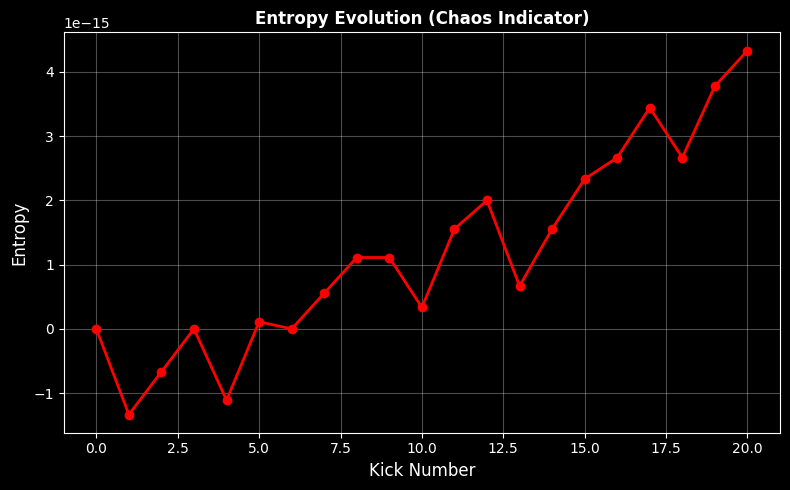

In [9]:
# Plot 2: Entropy evolution
fig_entropy, ax_entropy = plt.subplots(figsize=(8, 5))
ax_entropy.plot(range(len(entropy_list)), entropy_list, 'o-', 
                color='red', linewidth=2, markersize=6)
ax_entropy.set_xlabel('Kick Number', fontsize=12)
ax_entropy.set_ylabel('Entropy', fontsize=12)
ax_entropy.set_title('Entropy Evolution (Chaos Indicator)', fontsize=12, fontweight='bold')
ax_entropy.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

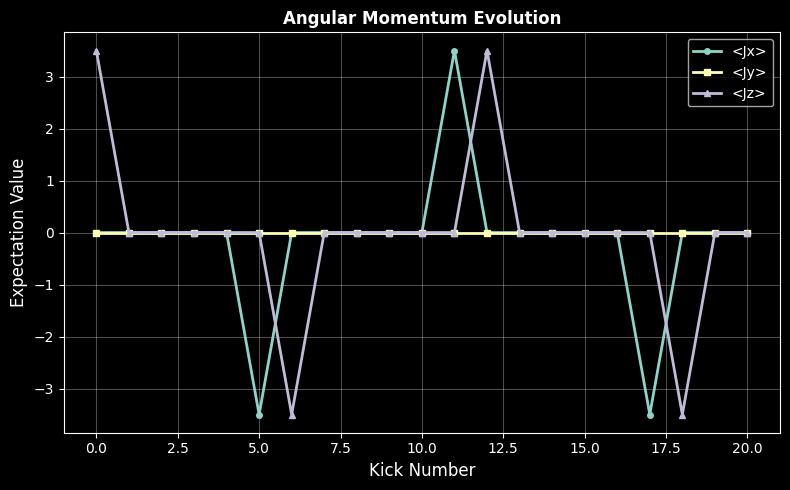

In [10]:
# Plot 3: Expectation values evolution
exp_array = np.array(exp_list)
kicks = np.arange(len(exp_list))
fig_exp, ax_exp = plt.subplots(figsize=(8, 5))
ax_exp.plot(kicks, exp_array[:, 0], 'o-', label='<Jx>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 1], 's-', label='<Jy>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 2], '^-', label='<Jz>', linewidth=2, markersize=4)
ax_exp.set_xlabel('Kick Number', fontsize=12)
ax_exp.set_ylabel('Expectation Value', fontsize=12)
ax_exp.set_title('Angular Momentum Evolution', fontsize=12, fontweight='bold')
ax_exp.legend(fontsize=10)
ax_exp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Compare Initial and Final States

Visualize the phase space evolution using different Wigner function projections from psyduck.plotting.

### Section 6.1: Hammer Projection

Visualize the phase space using Hammer projection from psyduck.plotting.

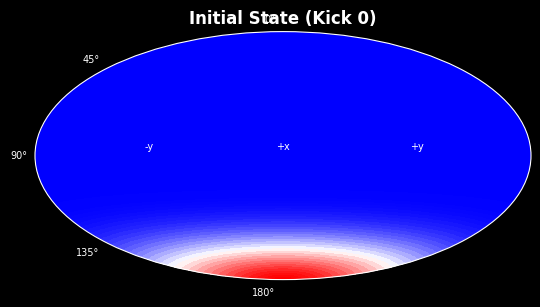

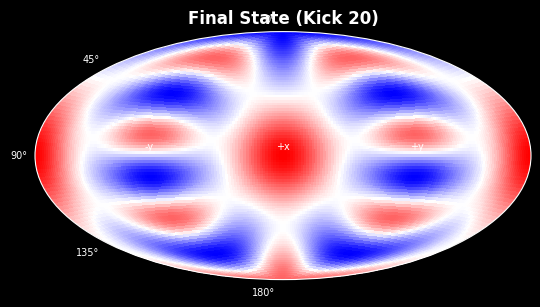

✓ Initial and final states compared
  Initial: Sharp peak indicating pure spin-coherent state
  Final: Spread distribution indicating decoherence/chaos


In [11]:
# Compare initial and final states using wigner_plot_hammer
# Initial state
fig_init, ax_init, _ = wigner_plot_hammer(psi_initial, n_theta=101, n_phi=201, cmap='bwr')
ax_init.set_title('Initial State (Kick 0)', fontsize=12, fontweight='bold')
plt.show()

# Final state
fig_final, ax_final, _ = wigner_plot_hammer(psi_list[-1], n_theta=101, n_phi=201, cmap='bwr')
ax_final.set_title(f'Final State (Kick {len(psi_list)-1})', fontsize=12, fontweight='bold')
plt.show()

print("✓ Initial and final states compared")
print(f"  Initial: Sharp peak indicating pure spin-coherent state")
print(f"  Final: Spread distribution indicating decoherence/chaos")

## Section 7: Dynamical Tunneling Analysis

Analyze tunneling dynamics by computing overlap (fidelity) with the initial state and identifying tunneling frequencies via FFT.

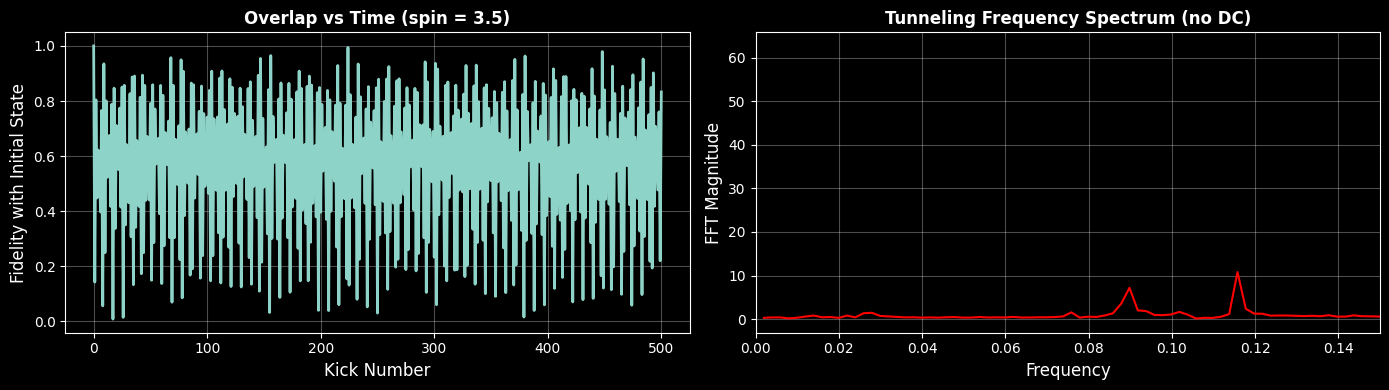

✓ Tunneling analysis completed for spin = 3.5
  Initial fidelity: 1.000000
  Final fidelity: 0.833023
  Fidelity evolution range: [0.008050, 1.000000]


In [12]:
# Single spin system tunneling analysis
spin = 3.5

# Create a new Spin object for tunneling analysis
tunnel_nucleus = Spin(I=spin)
tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
psi_tunnel_initial = tunnel_nucleus.state

# Run kicked dynamics for tunneling analysis
tau = 1.0
kappa = 3.0
n_kicks = 500

psi_tunnel_list, _, _, _ = kicked_dynamics(
    psi_tunnel_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
)

# Calculate overlap (fidelity) with initial state
overlap = np.zeros(len(psi_tunnel_list))
for i in range(len(psi_tunnel_list)):
    overlap[i] = qt.fidelity(psi_tunnel_list[0], psi_tunnel_list[i])

# Compute FFT
fft_vals = np.fft.fft(overlap)
fft_freqs = np.fft.fftfreq(len(overlap))

# Remove DC component
fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
fft_mag = np.abs(fft_vals_no_dc)

# Plot overlap and FFT
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Fidelity over time
axes[0].plot(np.arange(len(overlap)), overlap, linewidth=2, color='C0')
axes[0].set_xlabel('Kick Number', fontsize=12)
axes[0].set_ylabel('Fidelity with Initial State', fontsize=12)
axes[0].set_title(f'Overlap vs Time (spin = {spin})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: FFT magnitude spectrum
axes[1].plot(fft_freqs_no_dc, fft_mag, linewidth=1.5, color='red')
axes[1].set_xlim(0, 0.15)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('FFT Magnitude', fontsize=12)
axes[1].set_title('Tunneling Frequency Spectrum (no DC)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Tunneling analysis completed for spin = {spin}")
print(f"  Initial fidelity: {overlap[0]:.6f}")
print(f"  Final fidelity: {overlap[-1]:.6f}")
print(f"  Fidelity evolution range: [{np.min(overlap):.6f}, {np.max(overlap):.6f}]")

### 7.1 Compare Multiple Spins

Study how tunneling behavior depends on the spin quantum number.

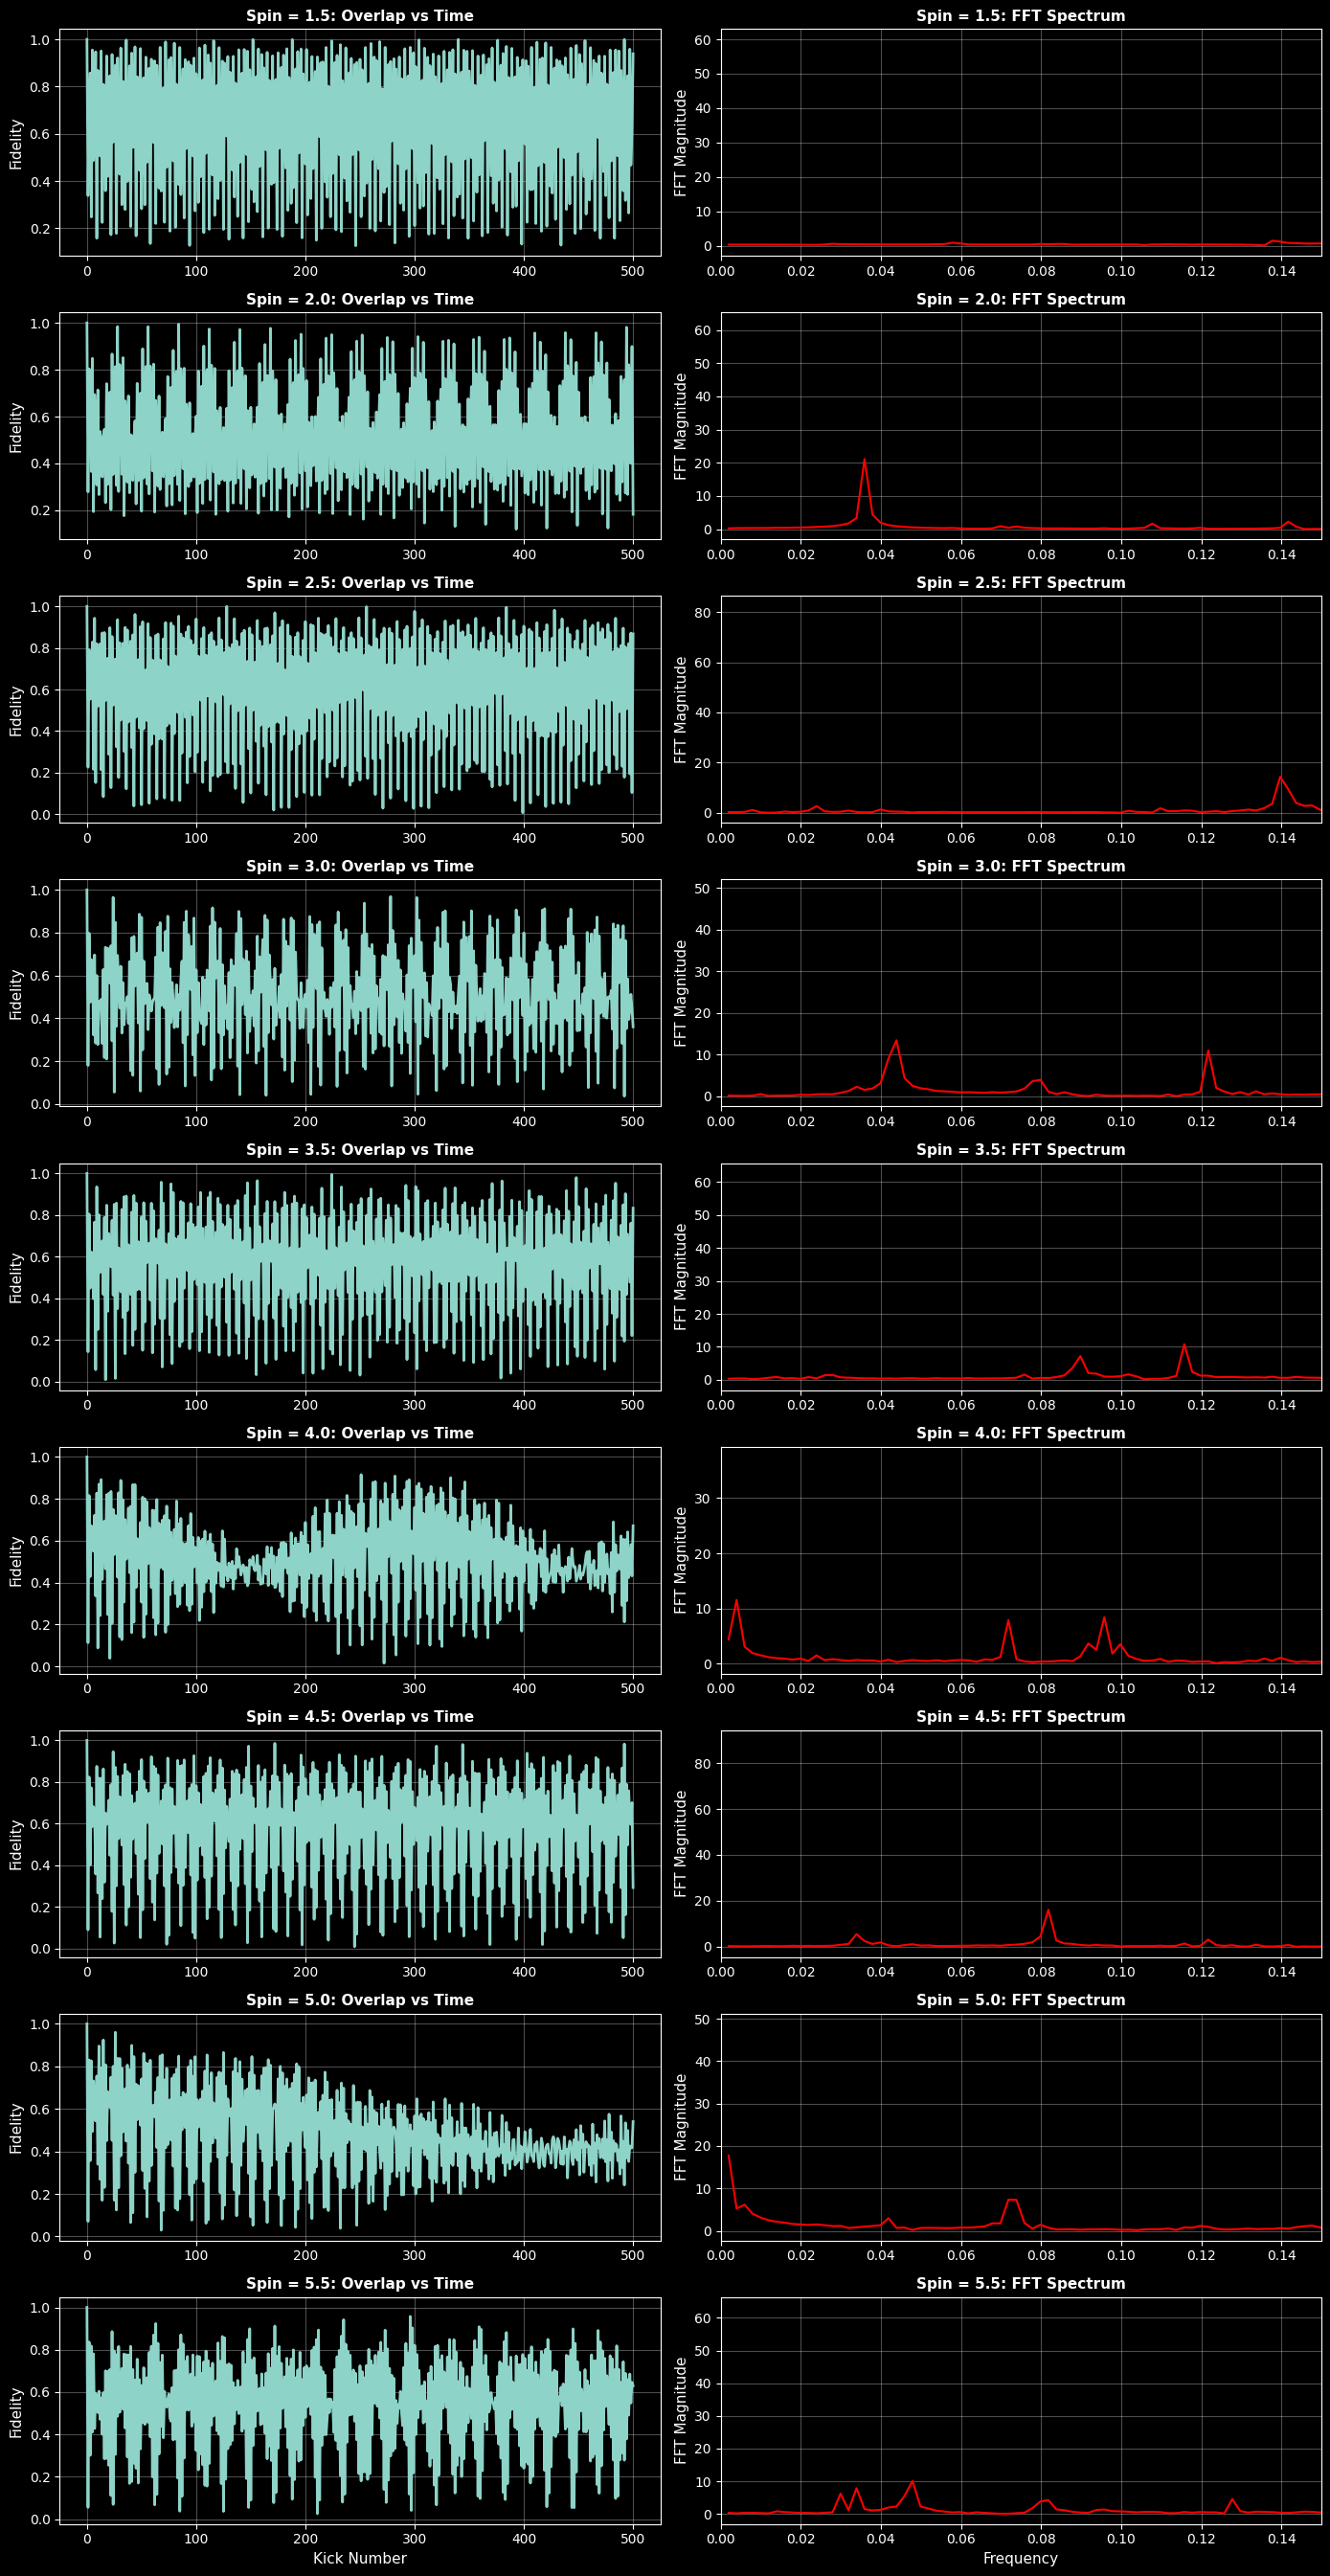

✓ Multi-spin tunneling analysis completed for 9 systems
  Spin values: [1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]
  Parameters: τ=1.0, κ=3.0, N=500
  Fidelity ranges by spin:
    I = 1.5: [0.1265, 1.0000]
    I = 2.0: [0.1197, 1.0000]
    I = 2.5: [0.0074, 1.0000]
    I = 3.0: [0.0362, 1.0000]
    I = 3.5: [0.0080, 1.0000]
    I = 4.0: [0.0151, 1.0000]
    I = 4.5: [0.0079, 1.0000]
    I = 5.0: [0.0294, 1.0000]
    I = 5.5: [0.0260, 1.0000]


In [13]:
# Multi-spin tunneling analysis
spin_values = np.arange(1.5, 6, 0.5)
n_spins = len(spin_values)

# Storage for results
overlaps = {}
fft_data = {}

# Common parameters
tau = 1.0
kappa = 3.0
n_kicks = 500

# Run analysis for each spin value
for spin in spin_values:
    # Create Spin object
    tunnel_nucleus = Spin(I=spin)
    tunnel_nucleus.make_displaced_coherent_state(theta=2.25, phi=0.7)
    psi_initial = tunnel_nucleus.state
    
    # Run kicked dynamics
    psi_list, _, _, _ = kicked_dynamics(
        psi_initial, tau, kappa, spin, N=n_kicks, order=2, pulse_type='pulse'
    )
    
    # Calculate overlap
    overlap = np.zeros(len(psi_list))
    for i in range(len(psi_list)):
        overlap[i] = qt.fidelity(psi_list[0], psi_list[i])
    
    overlaps[spin] = overlap
    
    # Compute FFT
    fft_vals = np.fft.fft(overlap)
    fft_freqs = np.fft.fftfreq(len(overlap))
    
    # Remove DC component
    fft_vals_no_dc = fft_vals[1:len(fft_vals)//2]
    fft_freqs_no_dc = fft_freqs[1:len(fft_vals)//2]
    fft_mag = np.abs(fft_vals_no_dc)
    
    fft_data[spin] = (fft_freqs_no_dc, fft_mag)

# Create subplot grid
fig, axes = plt.subplots(n_spins, 2, figsize=(14, 3*n_spins))

# Plot results for each spin
for idx, spin in enumerate(spin_values):
    # Left: Overlap vs time
    axes[idx, 0].plot(np.arange(len(overlaps[spin])), overlaps[spin], linewidth=2, color='C0')
    axes[idx, 0].set_ylabel('Fidelity', fontsize=11)
    axes[idx, 0].set_title(f'Spin = {spin}: Overlap vs Time', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Right: FFT spectrum
    fft_freqs, fft_mag = fft_data[spin]
    axes[idx, 1].plot(fft_freqs, fft_mag, linewidth=1.5, color='red')
    axes[idx, 1].set_xlim(0, 0.15)
    axes[idx, 1].set_ylabel('FFT Magnitude', fontsize=11)
    axes[idx, 1].set_title(f'Spin = {spin}: FFT Spectrum', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

# Set x-labels only on bottom row
for col in range(2):
    axes[-1, col].set_xlabel('Kick Number' if col == 0 else 'Frequency', fontsize=11)

plt.tight_layout()
plt.show()

print(f"✓ Multi-spin tunneling analysis completed for {n_spins} systems")
print(f"  Spin values: {spin_values}")
print(f"  Parameters: τ={tau}, κ={kappa}, N={n_kicks}")
print(f"  Fidelity ranges by spin:")
for spin in spin_values:
    overlap = overlaps[spin]
    print(f"    I = {spin}: [{np.min(overlap):.4f}, {np.max(overlap):.4f}]")

## Section 8: OTOC Simulation Tutorial

This section adapts `OTOC_simulation.ipynb` to the same `psyduck` workflow used above. We reuse `Spin.make_displaced_coherent_state()` for the probe state, `psyduck.evolve.kicked_dynamics()` for the kicked-top trajectory, and `ChaosQKT_functions.py` for the OTOC-specific basis-population post-processing.

We define the coherent-state projector `V = |theta, phi><theta, phi|`, a small rotation `W_eps = exp(-i eps n·J)`, and then evaluate the OTOC growth from the populations in the rotated basis:

`C_n = 1 - |sum_m p_n(m) exp(i eps m)|^2`.


In [18]:
# OTOC setup: build the coherent-state projector V and the perturbation W_eps
otoc_theta = np.pi / 4
otoc_phi = 0.0
eps = 0.35

otoc_spin = Spin(I=I)
otoc_spin.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
psi_otoc_initial = otoc_spin.state

V = qkt.spin_coherent_projector(I, otoc_theta, otoc_phi)
measurement_axis = np.array([
    np.sin(otoc_theta) * np.cos(otoc_phi),
    np.sin(otoc_theta) * np.sin(otoc_phi),
    np.cos(otoc_theta),
])
W_eps = (-1j * eps * (measurement_axis[0] * Ix + measurement_axis[1] * Iy + measurement_axis[2] * Iz)).expm()

print("OTOC operators prepared")
print(f"  theta = {otoc_theta:.3f}, phi = {otoc_phi:.3f}, eps = {eps:.3f}")
print(f"  ||[V, W_eps]|| = {qt.commutator(V, W_eps).norm():.3e}")


OTOC operators prepared
  theta = 0.785, phi = 0.000, eps = 0.350
  ||[V, W_eps]|| = 7.147e-16


### 8.1 Run the OTOC Trajectory

The propagation itself uses `kicked_dynamics`, so the only new logic is the OTOC readout: convert each state into populations in the tilted basis and then evaluate `C_n`.


In [19]:
# Reuse psyduck's kicked-top evolution and evaluate the OTOC after each kick
otoc_tau = 1.0
otoc_kappa = 3.5 * np.pi
otoc_kicks = 40

otoc_states, _, _, _ = kicked_dynamics(
    psi_otoc_initial, otoc_tau, otoc_kappa, I, N=otoc_kicks, order=2, pulse_type='pulse'
)
otoc_growth, otoc_populations, m_vals = qkt.otoc_trajectory(
    otoc_states, otoc_theta, otoc_phi, eps, I
)
kick_axis = np.arange(len(otoc_states))

print(f"Computed {len(otoc_states)} states across {otoc_kicks} kicks")
print(f"  C(0) = {otoc_growth[0]:.6f}")
print(f"  C({otoc_kicks}) = {otoc_growth[-1]:.6f}")
print(f"  rotated-basis m values: {m_vals}")


Computed 41 states across 40 kicks
  C(0) = 0.000000
  C(40) = 0.528430
  rotated-basis m values: [ 3.5  2.5  1.5  0.5 -0.5 -1.5 -2.5 -3.5]


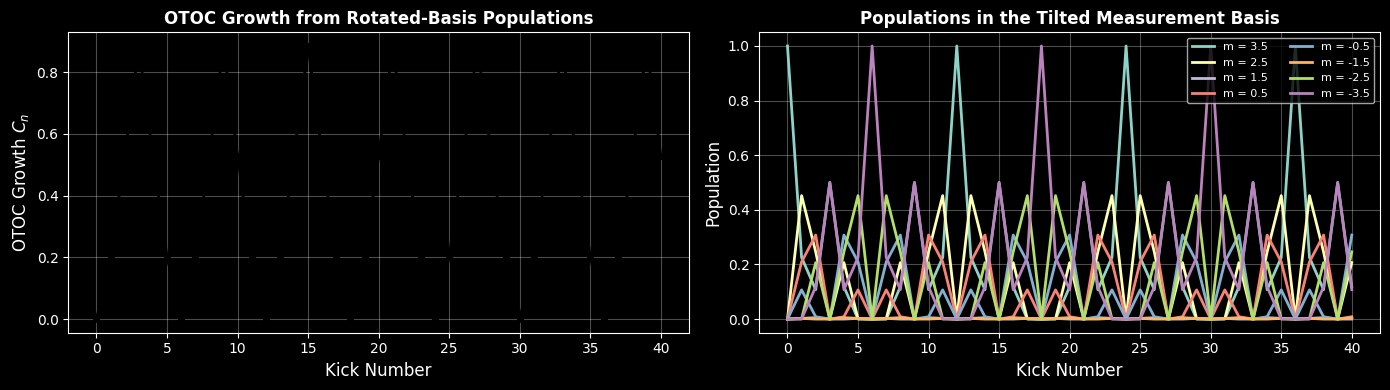

In [20]:
# Plot the OTOC growth together with the measurement-basis populations
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(kick_axis, otoc_growth, 'o-', linewidth=2, markersize=4, color='black')
axes[0].set_xlabel('Kick Number', fontsize=12)
axes[0].set_ylabel('OTOC Growth $C_n$', fontsize=12)
axes[0].set_title('OTOC Growth from Rotated-Basis Populations', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

for idx, m in enumerate(m_vals):
    axes[1].plot(kick_axis, otoc_populations[:, idx], linewidth=2, label=f'm = {m:g}')

axes[1].set_xlabel('Kick Number', fontsize=12)
axes[1].set_ylabel('Population', fontsize=12)
axes[1].set_title('Populations in the Tilted Measurement Basis', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


### 8.2 Sweep the Perturbation Strength

A simple way to explore the OTOC response is to keep the same kicked trajectory and vary `eps`, which changes the strength of the `W_eps` rotation in the readout.


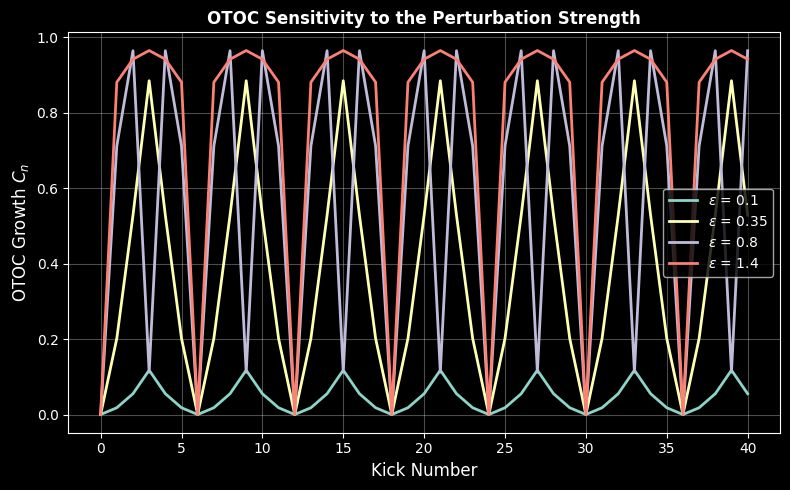

In [21]:
eps_values = [0.1, 0.35, 0.8, 1.4]

fig, ax = plt.subplots(figsize=(8, 5))
for eps_trial in eps_values:
    growth_trial, _, _ = qkt.otoc_trajectory(
        otoc_states, otoc_theta, otoc_phi, eps_trial, I
    )
    ax.plot(kick_axis, growth_trial, linewidth=2, label=fr'$\epsilon$ = {eps_trial}')

ax.set_xlabel('Kick Number', fontsize=12)
ax.set_ylabel('OTOC Growth $C_n$', fontsize=12)
ax.set_title('OTOC Sensitivity to the Perturbation Strength', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


Section 9 Trotterization

## Quick Reference

### Available Functions

#### From psyduck:
- `Spin(I=7/2)` - Create spin systems and prepare coherent states
  - `.make_displaced_coherent_state(theta, phi)` - Prepare a spin-coherent state
  - `.get_spin_operators()` - Get `(Ix, Iy, Iz)`
  - `.expectation(operator)` - Calculate expectation values
  - `.qudit_linear_entropy()` - Calculate linear entropy
  - `.state` - Current quantum state
- `psyduck.evolve.kicked_dynamics()` - Quantum kicked-top simulator
- `psyduck.plotting.wigner_plot_hammer()` - Hammer projection visualization

#### From ChaosQKT_functions:
- `spin_coherent_projector(j, theta, phi)` - Build the coherent-state projector used for `V`
- `probs_in_Hprime_basis(state, theta, phi, j)` - Populations in the tilted measurement basis
- `otoc_from_populations(m_vals, probs, eps)` - Convert populations into the complex OTOC amplitude
- `otoc_trajectory(states, theta, phi, eps, j)` - Compute `C_n = 1 - |F_n|^2` along a trajectory
- `normalize_data()`, `smooth_data()`, `downsample_data()` - Data processing utilities

### Key Points
- Sections 3-7 use `psyduck` for coherent-state preparation, kicked dynamics, and visualization.
- Section 8 adapts the standalone OTOC notebook into the same `psyduck` workflow.
- OTOC post-processing lives in `ChaosQKT_functions.py` because those helpers are not present in `psyduck` yet.
- The actual state propagation in the OTOC tutorial still uses `psyduck.evolve.kicked_dynamics()`.
